# Datos Faltantes

In [9]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer, KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Cargar el conjunto de datos
diabetes = load_diabetes(as_frame=True)
data = diabetes.data
data['target'] = diabetes.target

In [11]:
data.sample(10)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
346,0.005383,0.050680,0.017506,0.032201,0.127771,0.127390,-0.021311,0.071210,0.062578,0.015491,139.0
385,0.023546,0.050680,-0.019140,0.049415,-0.063487,-0.061125,0.004460,-0.039493,-0.025953,-0.013504,219.0
300,0.016281,-0.044642,0.073552,-0.041235,-0.004321,-0.013527,-0.013948,-0.001116,0.042897,0.044485,275.0
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207,215.0
42,-0.060003,0.050680,-0.010517,-0.014863,-0.049727,-0.023547,-0.058127,0.015858,-0.009919,-0.034215,61.0
311,0.096197,-0.044642,0.040140,-0.057313,0.045213,0.060690,-0.021311,0.036154,0.012551,0.023775,180.0
200,0.056239,-0.044642,-0.057941,-0.007977,0.052093,0.049103,0.056003,-0.021412,-0.028323,0.044485,158.0
271,0.038076,0.050680,0.008883,0.042529,-0.042848,-0.021042,-0.039719,-0.002592,-0.018114,0.007207,127.0
76,-0.030942,0.050680,0.028284,0.070072,-0.126781,-0.106845,-0.054446,-0.047981,-0.030748,0.015491,170.0


In [12]:
# Simular valores faltantes
np.random.seed(42)
data.loc[data.sample(frac=0.1).index, 'bmi'] = np.nan
data.loc[data.sample(frac=0.1).index, 'bp'] = np.nan

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado:

### 1. ¿Cuántos valores faltantes hay en cada columna?**

In [13]:
data.isnull().sum()

age        0
sex        0
bmi       44
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 2. Utiliza imputación simple (media) para llenar los valores faltantes de la columna 'bmi'.

In [19]:
#Primero cargo los datos copiandolos a un nuevo dataframe para no modificar el original  
data_simple = data.copy()

# La estrategia habitual para variables continuas es la media ('mean') o la mediana ('median')
imputer = SimpleImputer(strategy='mean')

# 2. Aplicar e imputar únicamente en la columna 'bmi'
data_simple[['bmi']] = imputer.fit_transform(data_simple[['bmi']])

# 3. Verificar que bmi ya no tiene nulos
print(data_simple[['bmi', 'bp']].isnull().sum())

data_simple.isnull().sum()

bmi     0
bp     44
dtype: int64


age        0
sex        0
bmi        0
bp        44
s1         0
s2         0
s3         0
s4         0
s5         0
s6         0
target     0
dtype: int64

### 3. Utiliza KNNImputer para imputar valores en las columnas 'bmi' y 'bp'. Compara los resultados con los de la imputación simple.

In [22]:
#Primero cargo los datos copiandolos a un nuevo dataframe para no modificar el original
data_knn = data.copy()

#1 Imputación con KNN
knn_imp = KNNImputer(n_neighbors=5)

# Es mejor imputar sobre todo el dataset para que KNN use las demás variables (age, sex, s1, etc.)
data_knn_imputed = pd.DataFrame(knn_imp.fit_transform(data_knn), columns=data_knn.columns)

# 3. Verificar que bmi ya no tiene nulos
print(data_knn_imputed[['bmi', 'bp']].isnull().sum())

data_knn_imputed.isnull().sum()

# 4. Tabla de Comparación Estadística
comparacion = pd.concat(
    {
        'Con Nulos': data[['bmi', 'bp']].agg(['mean', 'std']).T.rename(columns={'mean': 'Media', 'std': 'Desv_Std'}),
        'SimpleImputer': data_simple[['bmi', 'bp']].agg(['mean', 'std']).T.rename(columns={'mean': 'Media', 'std': 'Desv_Std'}),
        'KNNImputer': data_knn_imputed[['bmi', 'bp']].agg(['mean', 'std']).T.rename(columns={'mean': 'Media', 'std': 'Desv_Std'})
    },
    axis=1
)

print(comparacion)


bmi    0
bp     0
dtype: int64
    Con Nulos           SimpleImputer           KNNImputer          
        Media  Desv_Std         Media  Desv_Std      Media  Desv_Std
bmi -0.000205  0.046989     -0.000205  0.044583   0.000060  0.045621
bp   0.000465  0.048043      0.000465  0.048043   0.000292  0.046398


### 4. Genera un histograma comparando los datos antes y después de la imputación en la columna 'bmi'.

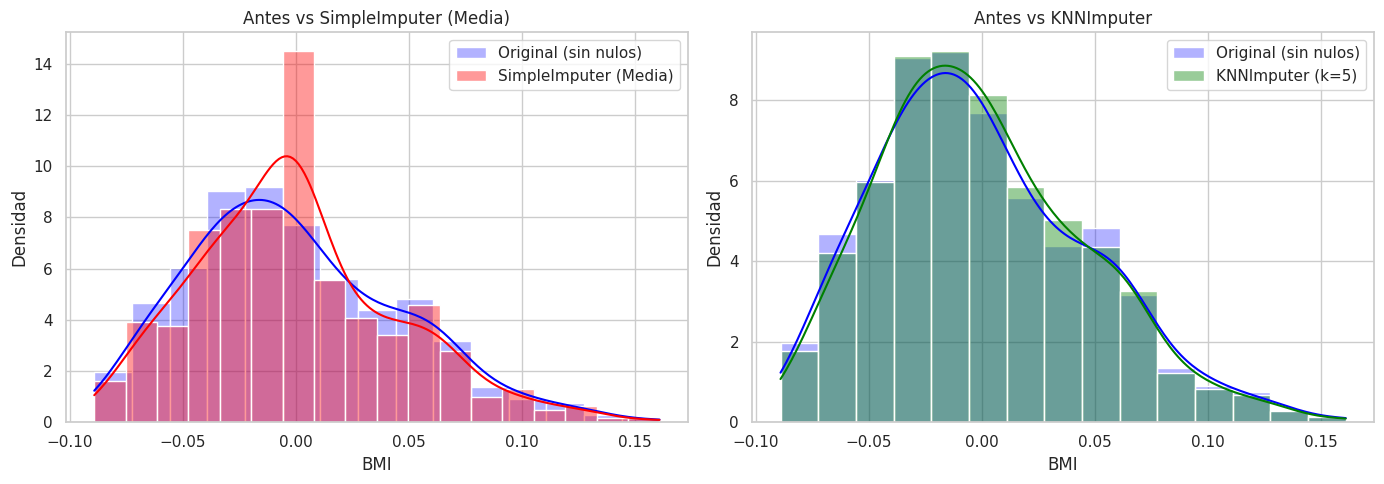

In [26]:
# gráfico comparativo
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel Izquierdo: Antes vs SimpleImputer
sns.histplot(
    data['bmi'].dropna(),
    kde=True,
    color='blue',
    label='Original (sin nulos)',
    ax=axes[0],
    alpha=0.3,
    stat='density',
)
sns.histplot(
    data_simple['bmi'],
    kde=True,
    color='red',
    label='SimpleImputer (Media)',
    ax=axes[0],
    alpha=0.4,
    stat='density',
)
axes[0].set_title('Antes vs SimpleImputer (Media)')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Panel Derecho: Antes vs KNNImputer
sns.histplot(
    data['bmi'].dropna(),
    kde=True,
    color='blue',
    label='Original (sin nulos)',
    ax=axes[1],
    alpha=0.3,
    stat='density',
)
sns.histplot(
    data_knn_imputed['bmi'],
    kde=True,
    color='green',
    label='KNNImputer (k=5)',
    ax=axes[1],
    alpha=0.4,
    stat='density',
)
axes[1].set_title('Antes vs KNNImputer')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Densidad')
axes[1].legend()

plt.tight_layout()
plt.show()

